# Phase 1C: Simplified Mel Feature Cache

**เป้าหมาย:** Pre-extract mel spectrogram จาก mp3 → บันทึกเป็น `.pt` สำหรับ train/val/test

## สิ่งที่เปลี่ยนจาก Phase 1B
| | Phase 1B (เดิม) | Phase 1C (ใหม่) |
|---|---|---|
| Input | mel + tabular 88 features | **mel only** |
| Storage | float16 | **float32** |
| Chunks/track (train) | 4 fixed | **8 random** |
| Random chunk | fixed ตอน extract | **สุ่มใหม่ทุก epoch** |
| Augmentation | noise + stretch + pitch + SpecAugment | **SpecAugment เท่านั้น** |
| Sampler | WeightedRandomSampler | **plain shuffle** |

## Output Format
```
output/pt_features/
├── training/   track_{id:06d}.pt  →  {'mel': (8, 128, 130) float32, 'label': int}
├── validation/ track_{id:06d}.pt  →  {'mel': (1, 128, 130) float32, 'label': int}
└── test/       track_{id:06d}.pt  →  {'mel': (1, 128, 130) float32, 'label': int}
```

## Prerequisites
1. `output/cleaned_metadata.csv` — จาก `fma_phase1a_eda.ipynb`
2. `output/skip_track_ids.txt`   — จาก `fma_phase1a_eda.ipynb`
3. `FMA_Data/fma_small/fma_small/` — audio source

## Cell 1: Imports & Configuration

In [1]:
import json
import random
import warnings
from pathlib import Path
from typing import Dict, Tuple

import numpy as np
import pandas as pd
import librosa
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# ==============================================================================
# PATHS
# ==============================================================================
NOTEBOOK_DIR  = Path().resolve()                   # data prep/
OUTPUT_DIR    = NOTEBOOK_DIR / 'output'
PT_DIR        = OUTPUT_DIR / 'pt_features'
METADATA_CSV  = OUTPUT_DIR / 'cleaned_metadata.csv'
SKIP_FILE     = OUTPUT_DIR / 'skip_track_ids.txt'
FMA_AUDIO_DIR = Path(r'D:\patt\project\pattern-music\FMA_Data\fma_small\fma_small')

# ==============================================================================
# AUDIO CONFIG
# ==============================================================================
SAMPLE_RATE     = 22050
CHUNK_DURATION  = 3.0
CHUNK_SAMPLES   = int(SAMPLE_RATE * CHUNK_DURATION)  # 66150
N_MELS          = 128
N_FFT           = 2048
HOP_LENGTH      = 512
MEL_FRAMES      = 130   # floor(66150/512)+1 = 130

# Global normalization stats (computed from training set in Phase 1A)
MEL_MEAN = -41.73837661743164
MEL_STD  = 13.906579971313477

# ==============================================================================
# DATASET CONFIG
# ==============================================================================
N_TRAIN_CHUNKS = 8     # random chunks per training track
BATCH_SIZE     = 64
NUM_WORKERS    = 0     # 0 = notebook-safe on Windows

GENRE_LABELS = [
    'Electronic', 'Experimental', 'Folk', 'Hip-Hop',
    'Instrumental', 'International', 'Pop', 'Rock'
]

print(f'Chunk duration : {CHUNK_DURATION}s ({CHUNK_SAMPLES} samples)')
print(f'Mel shape      : (1, {N_MELS}, {MEL_FRAMES})')
print(f'Train chunks   : {N_TRAIN_CHUNKS} per track')
print(f'MEL_MEAN={MEL_MEAN:.4f}  MEL_STD={MEL_STD:.4f}')
print(f'Audio dir      : {FMA_AUDIO_DIR}')
print(f'Audio exists   : {FMA_AUDIO_DIR.exists()}')

Chunk duration : 3.0s (66150 samples)
Mel shape      : (1, 128, 130)
Train chunks   : 8 per track
MEL_MEAN=-41.7384  MEL_STD=13.9066
Audio dir      : D:\patt\project\pattern-music\FMA_Data\fma_small\fma_small
Audio exists   : True


## Cell 2: Load & Validate Metadata

In [2]:
# โหลด metadata
metadata_df = pd.read_csv(METADATA_CSV)
assert {'track_id', 'genre_idx', 'split'}.issubset(metadata_df.columns), \
    'cleaned_metadata.csv ขาด column — รัน fma_phase1a_eda.ipynb ก่อน'

# โหลด skip IDs
with open(SKIP_FILE) as f:
    skip_ids = {int(x.strip()) for x in f if x.strip()}

# ลบ corrupted tracks
before = len(metadata_df)
metadata_df = metadata_df[~metadata_df['track_id'].isin(skip_ids)].copy()
metadata_df = metadata_df.reset_index(drop=True)
print(f'Tracks loaded  : {len(metadata_df):,} (removed {before - len(metadata_df)} skip IDs)')

split_counts = metadata_df['split'].value_counts()
print(f'\nSplit distribution:')
for split, count in split_counts.items():
    print(f'  {split:12s}: {count:,}')

Tracks loaded  : 7,985 (removed 0 skip IDs)

Split distribution:
  training    : 6,387
  test        : 800
  validation  : 798


## Cell 3: Disk Estimation

In [3]:
n_train = split_counts.get('training', 0)
n_val   = split_counts.get('validation', 0)
n_test  = split_counts.get('test', 0)

# ขนาดต่อไฟล์ (float32 = 4 bytes)
train_bytes = N_TRAIN_CHUNKS * N_MELS * MEL_FRAMES * 4 + 3000  # overhead ~3KB
eval_bytes  = 1 * N_MELS * MEL_FRAMES * 4 + 3000

total_bytes = n_train * train_bytes + (n_val + n_test) * eval_bytes
total_gb    = total_bytes / 1024**3

print('Estimated disk usage:')
print(f'  training   : {n_train:,} files × {train_bytes/1024:.0f} KB = {n_train*train_bytes/1e9:.2f} GB')
print(f'  validation : {n_val:,} files × {eval_bytes/1024:.0f} KB')
print(f'  test       : {n_test:,} files × {eval_bytes/1024:.0f} KB')
print(f'  TOTAL      : ~{total_gb:.2f} GB  (float32, mel only)')
print()
print('⚠️  output/pt_features/ จะถูก OVERWRITE ด้วย format ใหม่')

Estimated disk usage:
  training   : 6,387 files × 523 KB = 3.42 GB
  validation : 798 files × 68 KB
  test       : 800 files × 68 KB
  TOTAL      : ~3.29 GB  (float32, mel only)

⚠️  output/pt_features/ จะถูก OVERWRITE ด้วย format ใหม่


## Cell 4: Extraction Functions

In [4]:
def get_audio_path(track_id: int) -> Path:
    tid_str = f'{track_id:06d}'
    return FMA_AUDIO_DIR / tid_str[:3] / f'{tid_str}.mp3'


def extract_mel(audio: np.ndarray) -> np.ndarray:
    """
    Extract globally-normalized log-mel spectrogram.
    Input : audio (CHUNK_SAMPLES,) float32
    Output: mel   (1, 128, 130)   float32
    """
    mel = librosa.feature.melspectrogram(
        y=audio, sr=SAMPLE_RATE,
        n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS,
        power=2.0
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)  # (128, T)

    # Global normalization
    mel_db = (mel_db - MEL_MEAN) / (MEL_STD + 1e-8)

    # Pad หรือ crop ให้ได้ MEL_FRAMES พอดี
    if mel_db.shape[1] < MEL_FRAMES:
        pad = MEL_FRAMES - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0, 0), (0, pad)), mode='constant', constant_values=0.0)
    else:
        mel_db = mel_db[:, :MEL_FRAMES]

    return mel_db[np.newaxis].astype(np.float32)  # (1, 128, 130)


def cut_chunk(audio: np.ndarray, mode: str = 'random',
               rng: np.random.RandomState = None) -> np.ndarray:
    """
    ตัด 3s chunk จาก audio
    mode='center' → center crop (val/test)
    mode='random' → random position (train)
    """
    total = len(audio)
    if total < CHUNK_SAMPLES:
        padded = np.zeros(CHUNK_SAMPLES, dtype=np.float32)
        padded[:total] = audio
        return padded

    if mode == 'center':
        start = (total - CHUNK_SAMPLES) // 2
    else:
        if rng is None:
            rng = np.random.RandomState()
        start = rng.randint(0, total - CHUNK_SAMPLES + 1)

    return audio[start:start + CHUNK_SAMPLES].astype(np.float32)


def extract_chunks_for_track(
    audio: np.ndarray,
    n_chunks: int,
    mode: str = 'random'
) -> np.ndarray:
    """
    Extract n_chunks mel spectrograms จาก 1 track.
    mode='random' → n_chunks diverse random positions → (n_chunks, 128, 130)
    mode='center' → center crop เดียว              → (1, 128, 130)
    """
    if mode == 'center':
        chunk = cut_chunk(audio, mode='center')
        return extract_mel(chunk)  # (1, 128, 130)

    total = len(audio)
    rng   = np.random.RandomState()

    # สุ่ม start positions แบบ spread ออกตลอดเพลง
    # เพื่อลด chance ที่จะได้ chunk ซ้ำกัน
    if total <= CHUNK_SAMPLES:
        # เพลงสั้น → ใช้ center สำหรับทุก chunk
        mel = extract_mel(cut_chunk(audio, mode='center'))
        return np.repeat(mel, n_chunks, axis=0)  # (n_chunks, 128, 130)

    max_start = total - CHUNK_SAMPLES
    min_gap   = max_start // (n_chunks + 1)  # minimum distance between starts

    starts = []
    for i in range(n_chunks):
        # base position spread evenly + random offset
        base   = int(max_start * i / n_chunks)
        offset = rng.randint(-min_gap // 2, min_gap // 2 + 1)
        start  = int(np.clip(base + offset, 0, max_start))
        starts.append(start)

    mels = []
    for start in starts:
        chunk = audio[start:start + CHUNK_SAMPLES].astype(np.float32)
        mels.append(extract_mel(chunk))

    return np.concatenate(mels, axis=0)  # (n_chunks, 128, 130)


print('Extraction functions ready.')
print(f'  extract_mel()               → (1, {N_MELS}, {MEL_FRAMES}) float32')
print(f'  extract_chunks_for_track()  → (n_chunks, {N_MELS}, {MEL_FRAMES}) float32')

Extraction functions ready.
  extract_mel()               → (1, 128, 130) float32
  extract_chunks_for_track()  → (n_chunks, 128, 130) float32


## Cell 5: Run Pre-Extraction

**ตั้งค่า `OVERWRITE = True` สำหรับการรันครั้งแรก** (เพราะ format เปลี่ยน)

ถ้า kernel crash ระหว่างทาง ตั้ง `OVERWRITE = False` แล้วรันใหม่ — จะ skip ไฟล์ที่ทำไปแล้ว

In [5]:
OVERWRITE = True  # ← ตั้ง False ถ้า resume หลัง crash

for split_name in ['training', 'validation', 'test']:
    split_df  = metadata_df[metadata_df['split'] == split_name].copy()
    out_dir   = PT_DIR / split_name
    out_dir.mkdir(parents=True, exist_ok=True)

    is_train = (split_name == 'training')
    n_chunks = N_TRAIN_CHUNKS if is_train else 1
    mode     = 'random' if is_train else 'center'

    ok, fail, skip = 0, 0, 0
    print(f'\n[{split_name.upper()}] {len(split_df):,} tracks  →  {len(split_df)*n_chunks:,} chunks')

    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=split_name):
        track_id  = int(row['track_id'])
        genre_idx = int(row['genre_idx'])
        out_path  = out_dir / f'track_{track_id:06d}.pt'

        if not OVERWRITE and out_path.exists():
            skip += 1
            ok   += 1
            continue

        audio_path = get_audio_path(track_id)
        try:
            audio, _ = librosa.load(audio_path, sr=SAMPLE_RATE, mono=True)
            mel_chunks = extract_chunks_for_track(audio, n_chunks, mode=mode)
            # mel_chunks: (n_chunks, 128, 130)
            torch.save(
                {'mel': torch.from_numpy(mel_chunks), 'label': genre_idx},
                out_path
            )
            ok += 1
        except Exception as e:
            fail += 1
            print(f'  FAIL track_{track_id:06d}: {e}')

    print(f'  ✓ {ok:,} ok  |  {fail} failed  |  {skip:,} skipped')

print('\nExtraction complete.')


[TRAINING] 6,387 tracks  →  51,096 chunks


training:   0%|          | 0/6387 [00:00<?, ?it/s]

  ✓ 6,387 ok  |  0 failed  |  0 skipped

[VALIDATION] 798 tracks  →  798 chunks


validation:   0%|          | 0/798 [00:00<?, ?it/s]

  ✓ 798 ok  |  0 failed  |  0 skipped

[TEST] 800 tracks  →  800 chunks


test:   0%|          | 0/800 [00:00<?, ?it/s]

  ✓ 800 ok  |  0 failed  |  0 skipped

Extraction complete.


## Cell 6: FMAMelDataset

In [6]:
class FMAMelDataset(Dataset):
    """
    Load pre-extracted .pt files สำหรับ FMA genre classification.

    Training:
        - .pt มี mel shape (8, 128, 130) — 8 random chunks
        - __getitem__ สุ่มเลือก 1 chunk → (1, 128, 130)
        - SpecAugment applied with p=spec_augment_p

    Val / Test:
        - .pt มี mel shape (1, 128, 130) — center chunk
        - return ตรงๆ ไม่มี augmentation

    Returns:
        mel   : torch.float32  (1, 128, 130)
        label : torch.long     scalar
    """

    def __init__(
        self,
        pt_dir: Path,
        split: str,
        spec_augment_p: float = 0.5,
        freq_mask_max: int = 15,
        time_mask_max: int = 20,
        n_freq_masks: int  = 2,
        n_time_masks: int  = 2,
    ):
        self.pt_dir   = Path(pt_dir)
        self.is_train = (split == 'training')
        self.aug_p    = spec_augment_p if self.is_train else 0.0
        self.freq_max = freq_mask_max
        self.time_max = time_mask_max
        self.n_freq   = n_freq_masks
        self.n_time   = n_time_masks

        self.files = sorted(self.pt_dir.glob('*.pt'))
        if not self.files:
            raise FileNotFoundError(f'No .pt files in {self.pt_dir}')

        print(f'[{split}] {len(self.files):,} tracks | aug={self.is_train}')

    def __len__(self) -> int:
        return len(self.files)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        data  = torch.load(self.files[idx], weights_only=True)
        mel   = data['mel']   # float32, (n_chunks, 128, 130)
        label = torch.tensor(data['label'], dtype=torch.long)

        # สุ่ม chunk ใหม่ทุกครั้ง → random จริงต่อ epoch
        n_chunks = mel.shape[0]
        if self.is_train and n_chunks > 1:
            i   = torch.randint(0, n_chunks, (1,)).item()
            mel = mel[i]      # (128, 130)
        else:
            mel = mel[0]      # center chunk (128, 130)

        mel = mel.unsqueeze(0)  # → (1, 128, 130)

        # SpecAugment (training only, fill=0.0 = normalized mean)
        if self.is_train and random.random() < self.aug_p:
            mel = self._spec_augment(mel)

        return mel, label

    def _spec_augment(self, mel: torch.Tensor) -> torch.Tensor:
        mel = mel.clone()
        _, n_mels, n_frames = mel.shape

        # Frequency masking
        for _ in range(self.n_freq):
            f  = random.randint(0, self.freq_max)
            f0 = random.randint(0, max(0, n_mels - f))
            mel[:, f0:f0 + f, :] = 0.0

        # Time masking
        for _ in range(self.n_time):
            t  = random.randint(0, self.time_max)
            t0 = random.randint(0, max(0, n_frames - t))
            mel[:, :, t0:t0 + t] = 0.0

        return mel


print('FMAMelDataset defined.')

FMAMelDataset defined.


## Cell 7: DataLoader Factory

In [7]:
def create_dataloaders(
    pt_base_dir: Path = PT_DIR,
    batch_size:  int  = BATCH_SIZE,
    num_workers: int  = NUM_WORKERS,
) -> Dict[str, DataLoader]:
    """
    สร้าง DataLoader สำหรับ training / validation / test

    Design decisions:
    - shuffle=True (training): random (track, chunk) combination ต่อ epoch
    - shuffle=False (val/test): deterministic center-chunk evaluation
    - WeightedRandomSampler: ไม่ใช้ — FMA Small balance แล้ว (~800/genre)
    - drop_last=True (training): ป้องกัน last-batch size เล็กไป BatchNorm
    - persistent_workers=False: safe บน Windows Jupyter
    """
    loaders = {}

    for split_name in ['training', 'validation', 'test']:
        split_dir = Path(pt_base_dir) / split_name
        is_train  = (split_name == 'training')

        dataset = FMAMelDataset(pt_dir=split_dir, split=split_name)

        loaders[split_name] = DataLoader(
            dataset,
            batch_size  = batch_size,
            shuffle     = is_train,
            num_workers = num_workers,
            pin_memory  = True,
            drop_last   = is_train,
            persistent_workers = False,
        )

        n_batches = len(loaders[split_name])
        print(f'[{split_name:12s}] {len(dataset):,} tracks | {n_batches} batches | shuffle={is_train}')

    return loaders


loaders = create_dataloaders()
print('\nDataLoaders ready.')

[training] 31,935 tracks | aug=True
[training    ] 31,935 tracks | 498 batches | shuffle=True
[validation] 1,596 tracks | aug=False
[validation  ] 1,596 tracks | 25 batches | shuffle=False
[test] 1,600 tracks | aug=False
[test        ] 1,600 tracks | 25 batches | shuffle=False

DataLoaders ready.


## Cell 8: Verification — Shape & Normalization

In [8]:
print('=' * 55)
print('  VERIFICATION: Shape & Normalization')
print('=' * 55)

for split_name, loader in loaders.items():
    mel_b, label_b = next(iter(loader))
    bs = mel_b.shape[0]

    # Shape checks
    assert mel_b.shape[1:] == (1, N_MELS, MEL_FRAMES), \
        f'Wrong mel shape: {mel_b.shape}'
    assert mel_b.dtype  == torch.float32
    assert label_b.dtype == torch.long
    assert label_b.min() >= 0 and label_b.max() <= 7

    # NaN / Inf
    assert not torch.isnan(mel_b).any(), 'NaN in mel!'
    assert not torch.isinf(mel_b).any(), 'Inf in mel!'

    # Normalization sanity (ควรใกล้ N(0,1))
    m, s = mel_b.mean().item(), mel_b.std().item()

    print(f'\n[{split_name}]')
    print(f'  mel   : {tuple(mel_b.shape)}  {mel_b.dtype}')
    print(f'  label : {tuple(label_b.shape)}  {label_b.dtype}')
    print(f'  mean={m:.3f}  std={s:.3f}  (expect ≈ 0.0 / 1.0)')
    print(f'  label range: [{label_b.min().item()}, {label_b.max().item()}]')

print('\n  ✓ All assertions passed.')

  VERIFICATION: Shape & Normalization

[training]
  mel   : (64, 1, 128, 130)  torch.float32
  label : (64,)  torch.int64
  mean=0.125  std=1.053  (expect ≈ 0.0 / 1.0)
  label range: [0, 7]

[validation]
  mel   : (64, 1, 128, 130)  torch.float32
  label : (64,)  torch.int64
  mean=0.062  std=1.250  (expect ≈ 0.0 / 1.0)
  label range: [0, 7]

[test]
  mel   : (64, 1, 128, 130)  torch.float32
  label : (64,)  torch.int64
  mean=-0.025  std=1.136  (expect ≈ 0.0 / 1.0)
  label range: [1, 7]

  ✓ All assertions passed.


## Cell 9: Verification — Random Chunk per Epoch

In [9]:
# พิสูจน์ว่า Dataset สุ่ม chunk จริงต่อทุก call
ds_train = loaders['training'].dataset

# ปิด SpecAugment ชั่วคราว เพื่อให้ความต่างมาจาก chunk selection เท่านั้น
orig_p = ds_train.aug_p
ds_train.aug_p = 0.0

mels = [ds_train[0][0].numpy() for _ in range(6)]

diffs = [np.abs(mels[i] - mels[0]).mean() for i in range(1, 6)]
print('Mean absolute difference vs call-0 (same track, different chunk):')
for i, d in enumerate(diffs, 1):
    status = '✓ different' if d > 0.01 else '⚠ same'
    print(f'  Call {i}: {d:.4f}  {status}')

n_different = sum(d > 0.01 for d in diffs)
print(f'\n{n_different}/5 calls returned a different chunk.')
if n_different >= 3:
    print('  ✓ CONFIRMED: Random chunk selection working.')
else:
    print('  ⚠ WARNING: Chunks might not be diverse enough — check N_TRAIN_CHUNKS.')

# restore
ds_train.aug_p = orig_p

Mean absolute difference vs call-0 (same track, different chunk):
  Call 1: 0.6301  ✓ different
  Call 2: 0.6215  ✓ different
  Call 3: 0.5791  ✓ different
  Call 4: 0.6400  ✓ different
  Call 5: 0.6301  ✓ different

5/5 calls returned a different chunk.
  ✓ CONFIRMED: Random chunk selection working.


## Cell 10: Sample Spectrogram Visualization

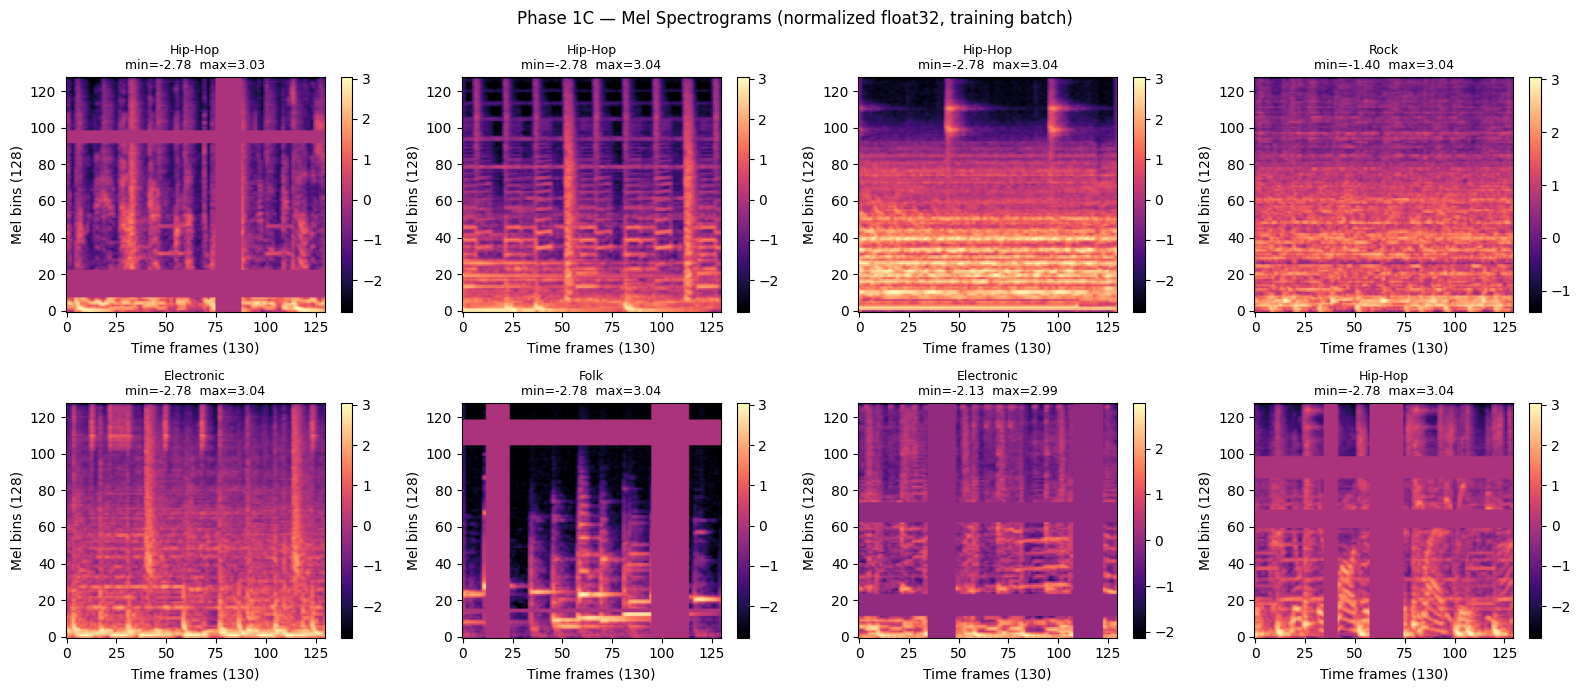

Saved → output/phase1c_sample_spectrograms.png


In [10]:
mel_b, label_b = next(iter(loaders['training']))

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, ax in enumerate(axes.flatten()):
    spec  = mel_b[i, 0].numpy()  # (128, 130)
    genre = GENRE_LABELS[label_b[i].item()]
    im = ax.imshow(spec, aspect='auto', origin='lower', cmap='magma')
    ax.set_title(f'{genre}\nmin={spec.min():.2f}  max={spec.max():.2f}', fontsize=9)
    ax.set_xlabel('Time frames (130)')
    ax.set_ylabel('Mel bins (128)')
    fig.colorbar(im, ax=ax)

fig.suptitle('Phase 1C — Mel Spectrograms (normalized float32, training batch)', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'phase1c_sample_spectrograms.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → output/phase1c_sample_spectrograms.png')

## Cell 11: Summary & Import Snippet

In [11]:
file_counts = {s: len(list((PT_DIR / s).glob('*.pt'))) for s in ['training', 'validation', 'test']}
actual_bytes = sum(
    f.stat().st_size
    for s in file_counts
    for f in (PT_DIR / s).glob('*.pt')
)

print('=' * 55)
print('  PHASE 1C COMPLETE')
print('=' * 55)
for s, c in file_counts.items():
    print(f'  {s:12s}: {c:,} .pt files')
print(f'  Disk used    : {actual_bytes/1e9:.2f} GB (float32, mel only)')
print(f'  training .pt : mel shape (8, 128, 130)')
print(f'  val/test .pt : mel shape (1, 128, 130)')
print()
print('  ── ใช้ใน Training Notebook ──')
print('''
  from pathlib import Path
  import sys
  sys.path.insert(0, str(Path("../data prep")))

  # copy class FMAMelDataset และ create_dataloaders จาก notebook นี้
  # แล้วเรียก:

  loaders = create_dataloaders(
      pt_base_dir = Path("../data prep/output/pt_features"),
      batch_size  = 64,
      num_workers = 0,   # 0 = notebook, 2-4 = script
  )

  # Each batch:
  #   mel   : (64, 1, 128, 130)  float32
  #   label : (64,)              int64
''')

  PHASE 1C COMPLETE
  training    : 31,935 .pt files
  validation  : 1,596 .pt files
  test        : 1,600 .pt files
  Disk used    : 4.47 GB (float32, mel only)
  training .pt : mel shape (8, 128, 130)
  val/test .pt : mel shape (1, 128, 130)

  ── ใช้ใน Training Notebook ──

  from pathlib import Path
  import sys
  sys.path.insert(0, str(Path("../data prep")))

  # copy class FMAMelDataset และ create_dataloaders จาก notebook นี้
  # แล้วเรียก:

  loaders = create_dataloaders(
      pt_base_dir = Path("../data prep/output/pt_features"),
      batch_size  = 64,
      num_workers = 0,   # 0 = notebook, 2-4 = script
  )

  # Each batch:
  #   mel   : (64, 1, 128, 130)  float32
  #   label : (64,)              int64

